#### Certified Data Scientist Project
#### Prediction: Employee Performance Analysis
#### Client: INX Future Inc
Problem Statement: Employee performance evaluation is a critical task for organizations to improve productivity and workforce management. The goal of this project is to analyze employee data from INX Future Inc and build a machine learning model capable of predicting employee performance ratings based on demographic, job-related, and satisfaction-related factors.


#### Project Summary

This project analyzes employee performance data from INX Future Inc.
The objective is to identify factors affecting employee performance
and build a predictive model to help HR make better hiring and
employee management decisions.

Several machine learning models including Logistic Regression,
Decision Tree, Random Forest and Support Vector Machine were trained.
Random Forest achieved the best performance.

Feature importance analysis revealed that Job Satisfaction,
Promotion Gap and Experience were the most significant factors
affecting employee performance.

Based on the insights obtained from the analysis, several
recommendations were proposed to improve employee productivity
and overall organizational performance.

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Loading the Data and basic checks

In [124]:
df = pd.read_excel("INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls")

In [125]:
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

In [127]:
df.describe()

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


In [128]:
df.isnull().sum()

EmpNumber                       0
Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
Attrition                       0
PerformanceRating               0
dtype: int64

In [129]:
df.duplicated().sum()

np.int64(0)

In [130]:
for c in df.columns:
    print(f"{c} : {df[c].unique()}\n")

EmpNumber : ['E1001000' 'E1001006' 'E1001007' ... 'E100994' 'E100995' 'E100998']

Age : [32 47 40 41 60 27 50 28 36 38 44 30 29 42 34 39 56 53 35 52 33 25 45 23
 26 54 37 24 49 55 43 51 22 31 58 20 21 48 19 18 59 46 57]

Gender : ['Male' 'Female']

EducationBackground : ['Marketing' 'Life Sciences' 'Human Resources' 'Medical' 'Other'
 'Technical Degree']

MaritalStatus : ['Single' 'Married' 'Divorced']

EmpDepartment : ['Sales' 'Human Resources' 'Development' 'Data Science'
 'Research & Development' 'Finance']

EmpJobRole : ['Sales Executive' 'Manager' 'Developer' 'Sales Representative'
 'Human Resources' 'Senior Developer' 'Data Scientist'
 'Senior Manager R&D' 'Laboratory Technician' 'Manufacturing Director'
 'Research Scientist' 'Healthcare Representative' 'Research Director'
 'Manager R&D' 'Finance Manager' 'Technical Architect' 'Business Analyst'
 'Technical Lead' 'Delivery Manager']

BusinessTravelFrequency : ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

DistanceFromHome : 

we have found that the data is clean there is no missing value or duplicate value. so,we can simply move to the EDA part. 

### EDA

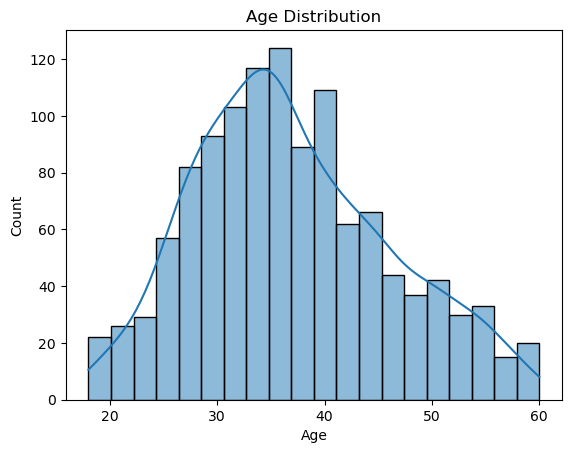

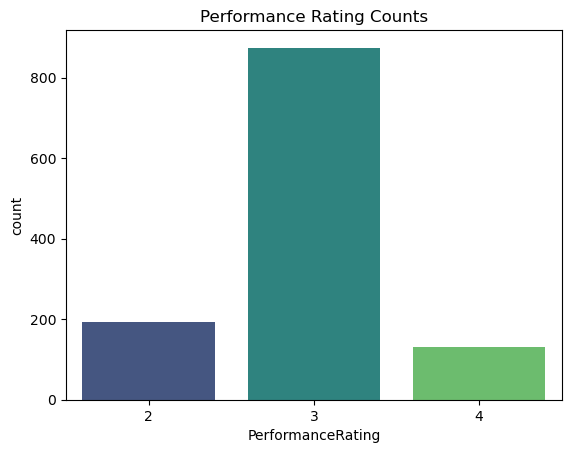

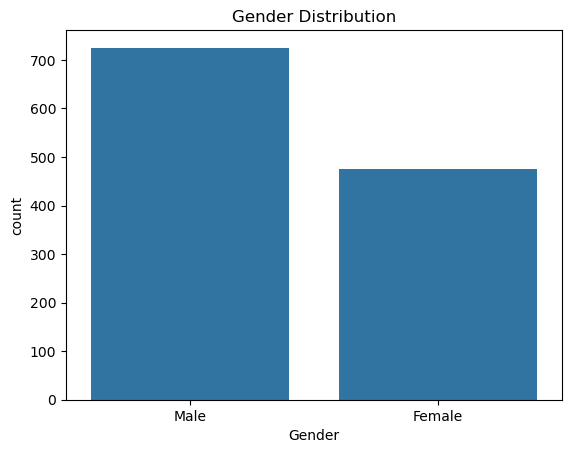

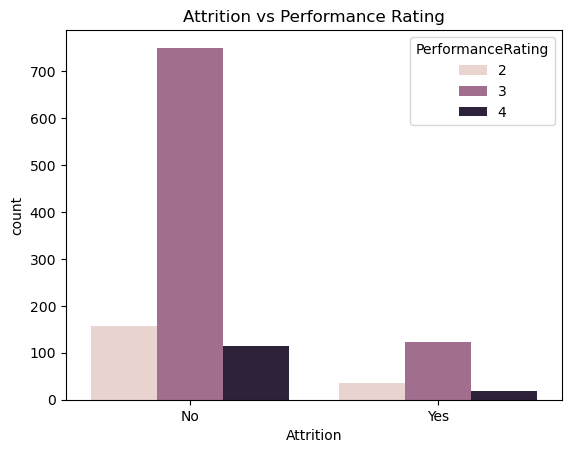

In [131]:
# Age distribution
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

# Performance Rating distribution
sns.countplot(x='PerformanceRating', data=df, palette="viridis")
plt.title("Performance Rating Counts")
plt.show()

# Gender distribution
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

# Attrition distribution
sns.countplot(x='Attrition', hue='PerformanceRating', data=df)
plt.title("Attrition vs Performance Rating")
plt.show()

The analysis above reveals that the company has a mid-career, moderately satisfied workforce with average performance ratings. Training opportunities and satisfaction levels stand out as potential areas for improvement, while demographic factors like age and gender appear balanced.

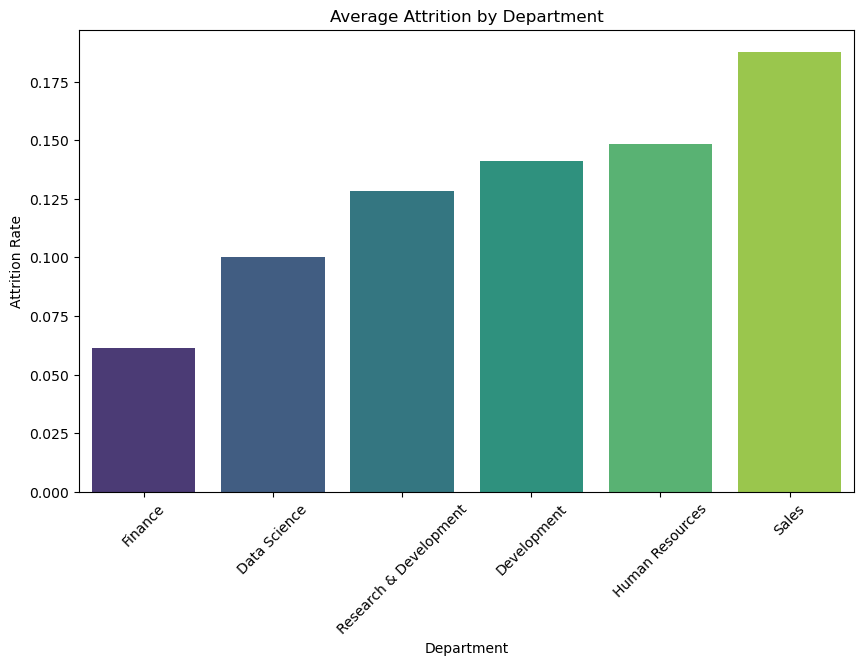

In [132]:
# Convert Attrition to numeric
df["Attrition_num"] = df["Attrition"].map({"Yes":1, "No":0})

# Group by department
dept_attrition = df.groupby("EmpDepartment")["Attrition_num"].mean().sort_values()

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=dept_attrition.index, y=dept_attrition.values, palette="viridis")

plt.title("Average Attrition by Department")
plt.ylabel("Attrition Rate")
plt.xlabel("Department")
plt.xticks(rotation=45)

plt.show()

- Analysis above shows attrition in sales department is very high compare to others. Management should investigate for attrition in sales and HR department

### Average Employee Performance by Department

In [133]:
dept_perf = df.groupby("EmpDepartment")["PerformanceRating"].mean().sort_values()

In [134]:
dept_perf

EmpDepartment
Finance                   2.775510
Sales                     2.860590
Research & Development    2.921283
Human Resources           2.925926
Data Science              3.050000
Development               3.085873
Name: PerformanceRating, dtype: float64

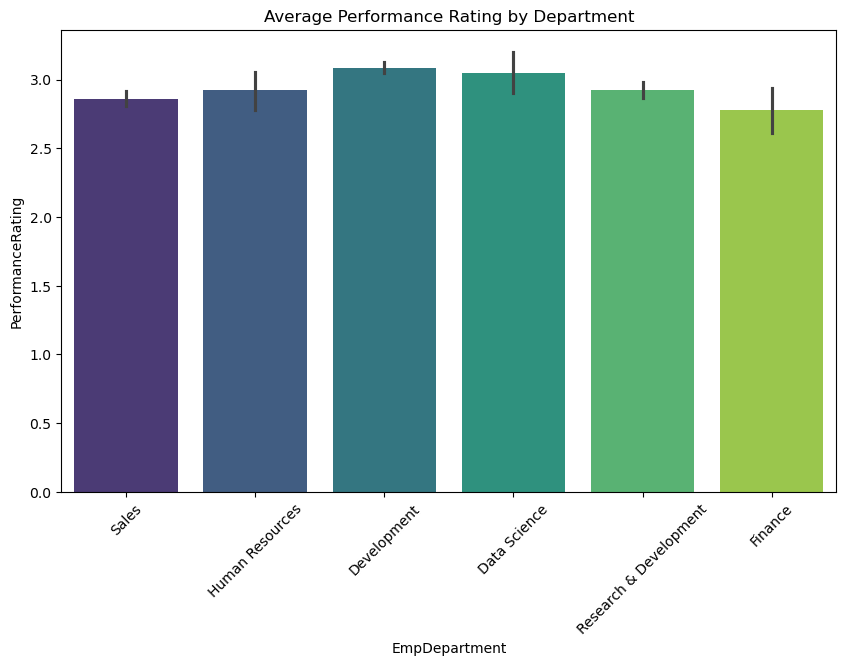

In [135]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x="EmpDepartment",
    y="PerformanceRating",
    estimator=np.mean,
    palette="viridis"
)
plt.title("Average Performance Rating by Department")
plt.xticks(rotation=45)
plt.show()

The department-wise analysis reveals that performance issues are not uniform across the company. Certain departments are thriving, while others are struggling. This insight allows management to focus improvement strategies on specific departments rather than applying blanket policies, ensuring interventions are both effective and morale-friendly.

In [136]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

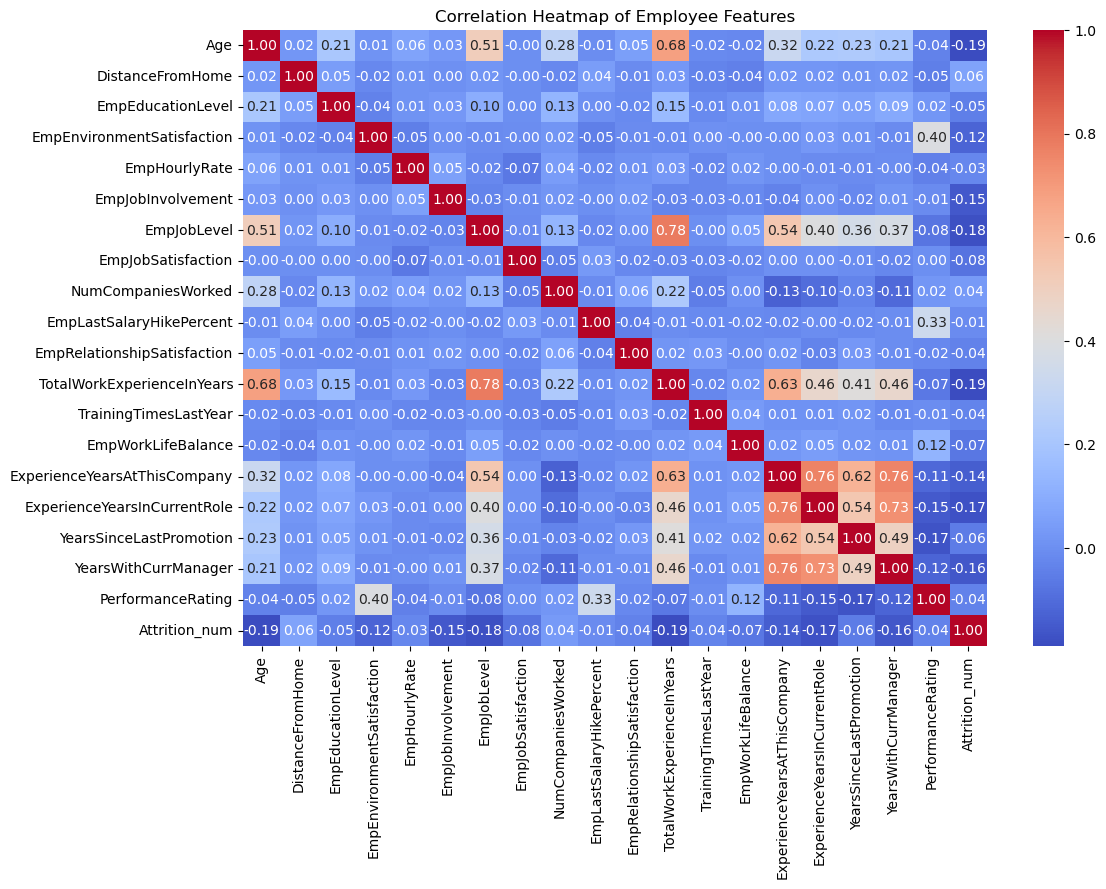

In [137]:
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Employee Features")
plt.show()

The correlation analysis highlights that employee satisfaction (job environment, work-life balance) and training opportunities are the most influential factors in driving performance. Demographic variables like age or marital status have minimal impact, reinforcing the importance of workplace culture and development programs over personal background.

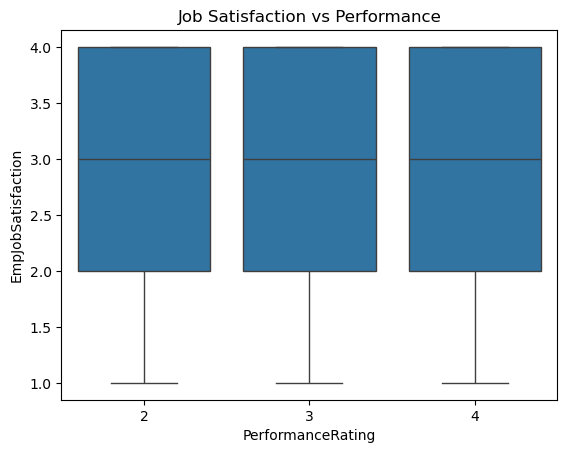

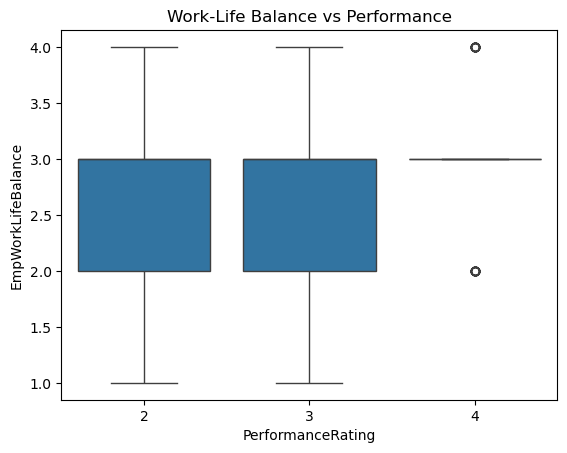

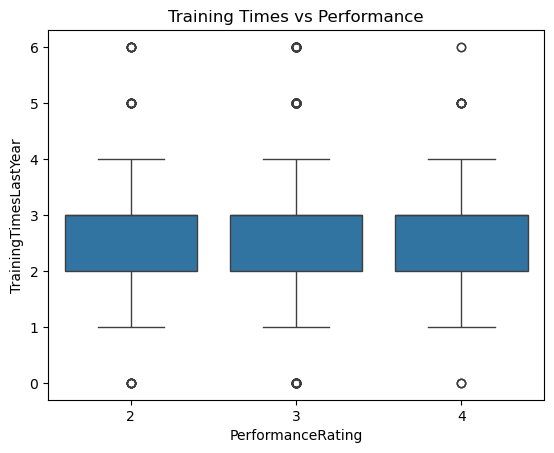

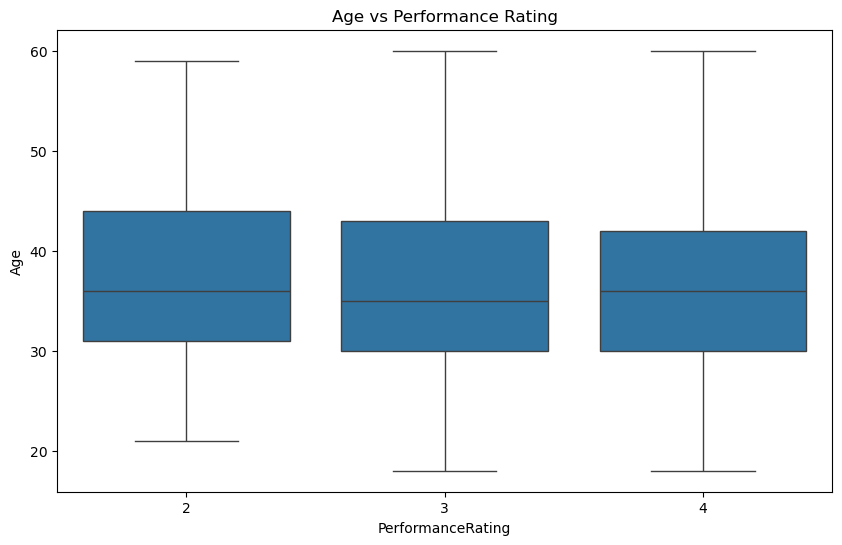

In [138]:
# Job Satisfaction vs Performance
sns.boxplot(x='PerformanceRating', y='EmpJobSatisfaction', data=df)
plt.title("Job Satisfaction vs Performance")
plt.show()

# Work-Life Balance vs Performance
sns.boxplot(x='PerformanceRating', y='EmpWorkLifeBalance', data=df)
plt.title("Work-Life Balance vs Performance")
plt.show()

# Training Times vs Performance
sns.boxplot(x='PerformanceRating', y='TrainingTimesLastYear', data=df)
plt.title("Training Times vs Performance")
plt.show()

# Age vs Performance
plt.figure(figsize=(10,6))
sns.boxplot(x='PerformanceRating', y='Age', data=df)
plt.title("Age vs Performance Rating")
plt.show()

The analysis above highlights that employee satisfaction (job, environment, work-life balance) and training opportunities are closely tied to performance outcomes. These factors should be prioritized in HR strategies to improve overall productivity and reduce attrition.

The exploratory data analysis revealed several patterns in employee performance. Employees with higher job satisfaction and work-life balance tend to receive higher performance ratings. Additionally, employees with more training sessions and higher job involvement demonstrate improved performance outcomes. These insights guided the feature engineering and modeling process.

### Feature Engineering

In [139]:
df.drop('EmpNumber', axis=1, inplace=True)

In [140]:
# Feature Engineering

df['PromotionGap'] = df['YearsSinceLastPromotion'] - df['ExperienceYearsInCurrentRole']

df['CompanyExperienceRatio'] = df['ExperienceYearsAtThisCompany'] / (df['TotalWorkExperienceInYears'] + 1)

df['WorkPressure'] = df['EmpJobInvolvement'] * df['OverTime'].map({'Yes':1, 'No':0})

In [141]:
df.head()

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,...,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating,Attrition_num,PromotionGap,CompanyExperienceRatio,WorkPressure
0,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,...,10,7,0,8,No,3,0,-7,0.909091,0
1,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,...,7,7,1,7,No,3,0,-6,0.333333,0
2,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,4,...,18,13,1,12,No,4,0,-12,0.857143,2
3,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,2,...,21,6,12,6,No,3,0,6,0.875000,0
4,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,1,...,2,2,2,2,No,3,0,0,0.181818,0


Feature engineering techniques were applied to create new variables capturing promotion delays, employee loyalty, and workload pressure. These derived features help the model capture complex relationships between employee experience, promotions, and work intensity that influence performance ratings.

### Scaling and Splitting 

In [142]:
from sklearn.preprocessing import OneHotEncoder
# Columns to encode
cols = ["EducationBackground", "MaritalStatus", "EmpDepartment", 
        "EmpJobRole", "BusinessTravelFrequency"]

encoder = OneHotEncoder(sparse_output=False, drop="first")
encoded = encoder.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cols))
df = df.drop(cols, axis=1)
df = pd.concat([df, encoded_df], axis=1)

In [143]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
#columns to encode
Lab_cols=['Gender','OverTime','Attrition']
for c in Lab_cols:
    df[c]= le.fit_transform(df[c])

In [144]:
X=df.drop(columns=['PerformanceRating','Attrition_num'])
Y=df['PerformanceRating']

In [148]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size= 0.2, random_state= 42)

In [149]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.fit_transform(x_test)

In [150]:
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (960, 56)
Testing Shape: (240, 56)


## Model Creation and Evaluation

In [151]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, roc_curve

### Logistic Regression

In [152]:
LR=LogisticRegression(max_iter=1000,class_weight="balanced")
#Hyper parameters defining
param_grid={'penalty':['l1','l2','elastinet'],
            'C':[0.01,0.1,1,10],
            'solver':['lbfgs','liblinear','saga']}
#Hper Parameters Tuning
grid_search_lr=GridSearchCV(estimator=LR,
                         param_grid=param_grid,
                         cv=5,
                         scoring='accuracy',
                         n_jobs=-1)
grid_search_lr.fit(X_train, y_train)
print('Best Parameters:',grid_search_lr.best_params_)

Best Parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}


In [153]:
best_model_LR = grid_search_lr.best_estimator_
y_pred_LR = best_model_LR.predict(X_test)
y_prob_LR = best_model_LR.predict_proba(X_test)

In [154]:
print("Accuracy:", accuracy_score(y_test, y_pred_LR))
print('ROC AUC Score:' ,roc_auc_score(y_test, y_prob_LR,multi_class='ovr'))
print(classification_report(y_test, y_pred_LR))
cm= confusion_matrix(y_test, y_pred_LR)
print('Confusion Matrix:')
print(cm)

Accuracy: 0.8
ROC AUC Score: 0.9101896488451237
              precision    recall  f1-score   support

           2       0.43      0.69      0.53        29
           3       0.92      0.83      0.87       184
           4       0.69      0.74      0.71        27

    accuracy                           0.80       240
   macro avg       0.68      0.75      0.71       240
weighted avg       0.84      0.80      0.81       240

Confusion Matrix:
[[ 20   6   3]
 [ 26 152   6]
 [  0   7  20]]


In [155]:
# Predictions
y_train_pred_LR = best_model_LR.predict(X_train)
y_test_pred_LR = best_model_LR.predict(X_test)
# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred_LR)
test_accuracy = accuracy_score(y_test, y_test_pred_LR)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
difference = train_accuracy - test_accuracy

if difference > 0.10:
    print("Model is Overfitting")
elif difference < -0.10:
    print("Model is Underfitting")
else:
    print("Model is Generalised")

Training Accuracy: 0.8114583333333333
Testing Accuracy: 0.8
Model is Generalised


The Logistic regression Model is generalised with a good accuracy of 0.81 for training data and 0.79 for testing data

### Decision Tree

In [156]:
DT=DecisionTreeClassifier(random_state=42,class_weight="balanced")
param_grid = {
    'criterion': ['gini', 'entropy'],   
    'max_depth': [3, 5, 10],                 
    'min_samples_split': [10, 20, 50],                
    'min_samples_leaf': [5, 10, 20],                  
    'max_features': ['sqrt', 'log2'],
    'ccp_alpha': [0.01, 0.05, 0.1]
}
grid_search_dt = GridSearchCV(
    estimator=DT,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search_dt.fit(X_train, y_train)
print("Best Parameters:", grid_search_dt.best_params_)

Best Parameters: {'ccp_alpha': 0.01, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 10}


In [157]:
best_model_DT = grid_search_dt.best_estimator_
y_pred_DT = best_model_DT.predict(X_test)
y_prob_DT = best_model_DT.predict_proba(X_test)

In [158]:
print("Accuracy:", accuracy_score(y_test, y_pred_DT))
print('ROC AUC Score:' ,roc_auc_score(y_test, y_prob_DT,multi_class='ovr'))
print(classification_report(y_test, y_pred_DT))
cm= confusion_matrix(y_test, y_pred_DT)
print('Confusion Matrix:')
print(cm)

Accuracy: 0.6791666666666667
ROC AUC Score: 0.8780691257634272
              precision    recall  f1-score   support

           2       0.50      0.97      0.66        29
           3       0.94      0.62      0.75       184
           4       0.32      0.74      0.45        27

    accuracy                           0.68       240
   macro avg       0.59      0.78      0.62       240
weighted avg       0.82      0.68      0.71       240

Confusion Matrix:
[[ 28   1   0]
 [ 27 115  42]
 [  1   6  20]]


In [159]:
# Predictions
y_train_pred_DT = best_model_DT.predict(X_train)
y_test_pred_DT = best_model_DT.predict(X_test)
# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred_DT)
test_accuracy = accuracy_score(y_test, y_test_pred_DT)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
difference = train_accuracy - test_accuracy

if difference > 0.10:
    print("Model is Overfitting")
elif difference < -0.10:
    print("Model is Underfitting")
else:
    print("Model is Generalised")

Training Accuracy: 0.6416666666666667
Testing Accuracy: 0.6791666666666667
Model is Generalised


The Decision Tree model showed poor predictive performance with low accuracy on both training and test data. This indicates that the model is not able to capture the underlying patterns effectively. Therefore, it is not suitable for predicting employee performance in this dataset.

### Random Forest

In [160]:
RF=RandomForestClassifier(random_state=42,class_weight="balanced")
param_grid = {
    'n_estimators': [100, 200, 500],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}
grid_search_rf = GridSearchCV(
    estimator=RF,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search_rf.fit(X_train, y_train)
print("Best Parameters:", grid_search_rf.best_params_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [161]:
best_model_RF = grid_search_rf.best_estimator_
y_pred_RF = best_model_RF.predict(X_test)
y_prob_RF = best_model_RF.predict_proba(X_test)

In [162]:
print("Accuracy:", accuracy_score(y_test, y_pred_RF))
print('ROC AUC Score:' ,roc_auc_score(y_test, y_prob_RF,multi_class='ovr'))
print(classification_report(y_test, y_pred_RF))
cm= confusion_matrix(y_test, y_pred_RF)
print('Confusion Matrix:')
print(cm)

Accuracy: 0.9333333333333333
ROC AUC Score: 0.9432126139489565
              precision    recall  f1-score   support

           2       0.90      0.90      0.90        29
           3       0.94      0.98      0.96       184
           4       0.95      0.67      0.78        27

    accuracy                           0.93       240
   macro avg       0.93      0.85      0.88       240
weighted avg       0.93      0.93      0.93       240

Confusion Matrix:
[[ 26   3   0]
 [  3 180   1]
 [  0   9  18]]


In [163]:
# Predictions
y_train_pred_RF = best_model_RF.predict(X_train)
y_test_pred_RF = best_model_RF.predict(X_test)
# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred_RF)
test_accuracy = accuracy_score(y_test, y_test_pred_RF)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
difference = train_accuracy - test_accuracy

if difference > 0.10:
    print("Model is Overfitting")
elif difference < -0.10:
    print("Model is Underfitting")
else:
    print("Model is Generalised")

Training Accuracy: 0.9958333333333333
Testing Accuracy: 0.9333333333333333
Model is Generalised


The Random Forest model is the best performing among all it is not only generalised but also gives the highest accuracy of 0.99 for training data and 0.93 for testing data

### Support Vector Machine

In [164]:
SVM = SVC(class_weight="balanced", random_state=42, probability=True)

param_grid = {
    'C': [0.01, 0.1, 1],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3]  # only relevant if 'poly' kernel is included
}

grid_search_svm = GridSearchCV(
    estimator=SVM,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_svm.fit(X_train, y_train)

print("Best Parameters:", grid_search_svm.best_params_)

Best Parameters: {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}


In [165]:
best_model_SVM = grid_search_svm.best_estimator_
y_pred_SVM = best_model_SVM.predict(X_test)
y_prob_SVM = best_model_SVM.predict_proba(X_test)

In [166]:
print("Accuracy:", accuracy_score(y_test, y_pred_SVM))
print('ROC AUC Score:' ,roc_auc_score(y_test, y_prob_SVM,multi_class='ovr'))
print(classification_report(y_test, y_pred_SVM))
cm= confusion_matrix(y_test, y_pred_SVM)
print('Confusion Matrix:')
print(cm)

Accuracy: 0.7416666666666667
ROC AUC Score: 0.8727058874410947
              precision    recall  f1-score   support

           2       0.41      0.79      0.54        29
           3       0.90      0.76      0.82       184
           4       0.55      0.59      0.57        27

    accuracy                           0.74       240
   macro avg       0.62      0.71      0.64       240
weighted avg       0.80      0.74      0.76       240

Confusion Matrix:
[[ 23   5   1]
 [ 33 139  12]
 [  0  11  16]]


In [167]:
# Predictions
y_train_pred_SVM = best_model_SVM.predict(X_train)
y_test_pred_SVM = best_model_SVM.predict(X_test)
# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred_SVM)
test_accuracy = accuracy_score(y_test, y_test_pred_SVM)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
difference = train_accuracy - test_accuracy

if difference > 0.10:
    print("Model is Overfitting")
elif difference < -0.10:
    print("Model is Underfitting")
else:
    print("Model is Generalised")

Training Accuracy: 0.8854166666666666
Testing Accuracy: 0.7416666666666667
Model is Overfitting


The SVM model here shows slight overfitting even after narrowing the param grid, that suggests the issue might not just be hyperparameters—it could be the model’s inherent flexibility relative to your dataset.

### Model Comparison Report

In [168]:
data = {
    "Metric": [
        "Train Accuracy", "Test Accuracy", "ROC-AUC",
        "Class 2 Precision (Test)", "Class 2 Recall (Test)", "Class 2 F1-score (Test)",
        "Class 3 Precision (Test)", "Class 3 Recall (Test)", "Class 3 F1-score (Test)",
        "Class 4 Precision (Test)", "Class 4 Recall (Test)", "Class 4 F1-score (Test)",
        "Generalization", "Class Imbalance Handling"
    ],
    "Logistic Regression": [
        "81%", "80%", 0.91, 0.43, 0.69, 0.53, 0.92, 0.83, 0.87, 0.69, 0.74, 0.71, "Strong", "Good"
    ],
    "Decision Tree": [
        "64%", "67%", 0.87, 0.50, 0.97, 0.66, 0.94, 0.62, 0.75, 0.32, 0.74, 0.45, "Good", "Weeak"
    ],
    "Random Forest": [
        "99%", "93%", 0.94, 0.90, 0.90, 0.90, 0.94, 0.98, 0.96, 0.95, 0.67, 0.78, "Strong", "Improved"
    ],
    "Support Vector Machine": [
        "88%", "74%", 0.87, 0.41, 0.79, 0.54, 0.90, 0.76, 0.82, 0.55, 0.59, 0.57, "Strong", "Imbalance"
    ]
}

# Convert to DataFrame
data = pd.DataFrame(data)

# Display table
print(data.to_string(index=False))


                  Metric Logistic Regression Decision Tree Random Forest Support Vector Machine
          Train Accuracy                 81%           64%           99%                    88%
           Test Accuracy                 80%           67%           93%                    74%
                 ROC-AUC                0.91          0.87          0.94                   0.87
Class 2 Precision (Test)                0.43           0.5           0.9                   0.41
   Class 2 Recall (Test)                0.69          0.97           0.9                   0.79
 Class 2 F1-score (Test)                0.53          0.66           0.9                   0.54
Class 3 Precision (Test)                0.92          0.94          0.94                    0.9
   Class 3 Recall (Test)                0.83          0.62          0.98                   0.76
 Class 3 F1-score (Test)                0.87          0.75          0.96                   0.82
Class 4 Precision (Test)                

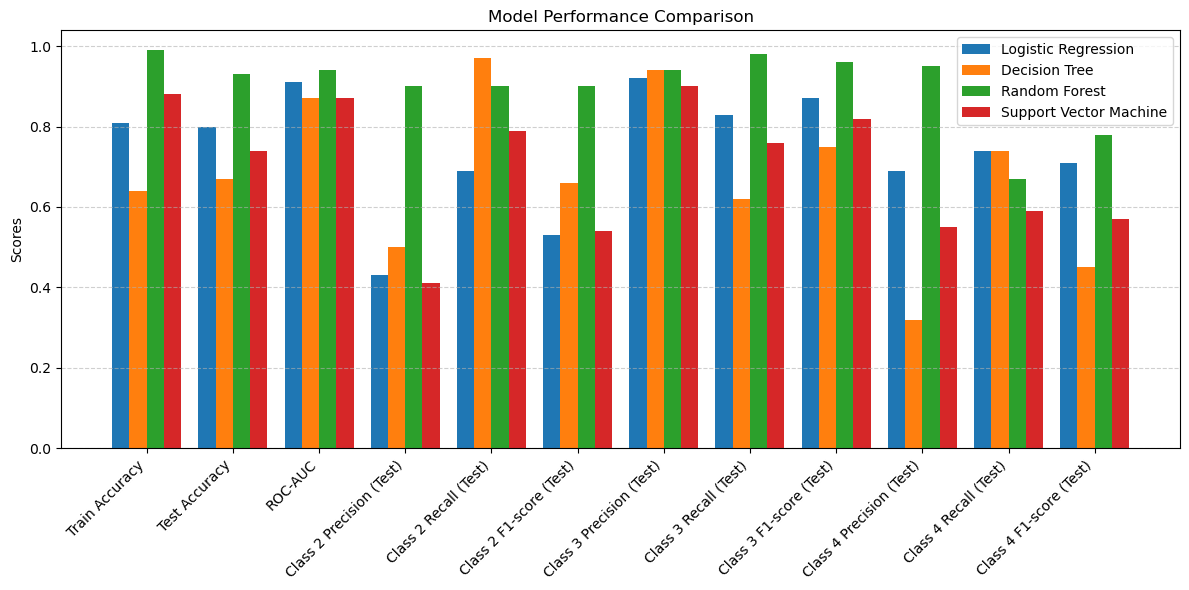

In [169]:
metrics = [
    "Train Accuracy", "Test Accuracy", "ROC-AUC",
    "Class 2 Precision (Test)", "Class 2 Recall (Test)", "Class 2 F1-score (Test)",
    "Class 3 Precision (Test)", "Class 3 Recall (Test)", "Class 3 F1-score (Test)",
    "Class 4 Precision (Test)", "Class 4 Recall (Test)", "Class 4 F1-score (Test)",
]

# Scores for each model
logistic = [0.81, 0.80, 0.91, 0.43, 0.69, 0.53, 0.92, 0.83, 0.87, 0.69, 0.74, 0.71]
decision_tree = [0.64, 0.67, 0.87, 0.50, 0.97, 0.66, 0.94, 0.62, 0.75, 0.32, 0.74, 0.45]
random_forest = [0.99, 0.93, 0.94, 0.90, 0.90, 0.90, 0.94, 0.98, 0.96, 0.95, 0.67, 0.78]
svm = [0.88, 0.74, 0.87, 0.41, 0.79, 0.54, 0.90, 0.76, 0.82, 0.55, 0.59, 0.57]

# X locations
x = np.arange(len(metrics))
width = 0.2  # width of each bar

# Plot
plt.figure(figsize=(12,6))
plt.bar(x - 1.5*width, logistic, width, label="Logistic Regression")
plt.bar(x - 0.5*width, decision_tree, width, label="Decision Tree")
plt.bar(x + 0.5*width, random_forest, width, label="Random Forest")
plt.bar(x + 1.5*width, svm, width, label="Support Vector Machine")


# Labels and formatting
plt.ylabel("Scores")
plt.title("Model Performance Comparison")
plt.xticks(x, metrics, rotation=45, ha="right")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

#### key insights from comparison report
- Best generalizer: Random Forest — strong across all classes, least overfitting.
- Most stable baseline: Logistic Regression — interpretable and balanced.
- Overfitting risk: Decision Tree — good in training but weaker in test generalization.
- Imbalance sensitivity: SVM — sharp boundaries but struggles with minority class recall.
we can say, Random Forest is the most reliable choice for generalization and class balance in your dataset, while Logistic Regression is a safe baseline. SVM and Decision Tree need careful tuning or balancing strategies to avoid bias.


### Factors Affecting Employee Performance

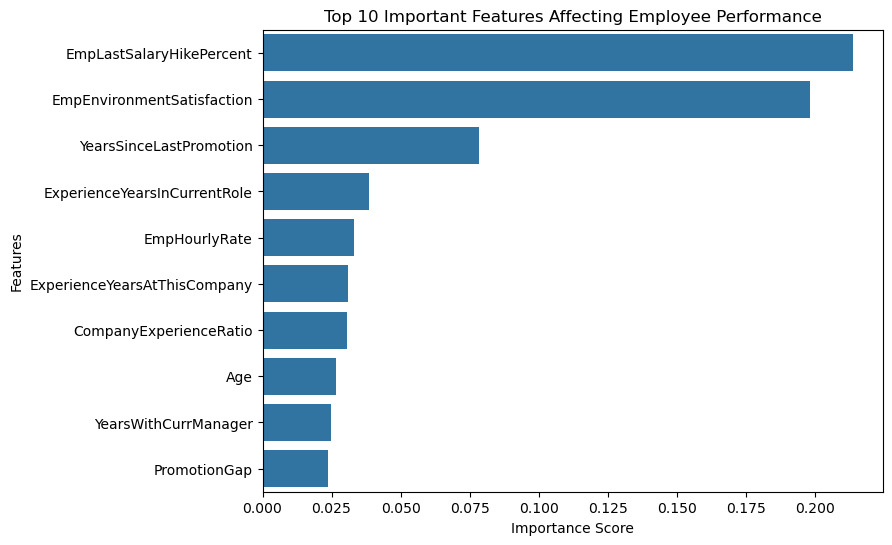

In [39]:
feature_importances = pd.Series(
    best_model_RF.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title("Top 10 Important Features Affecting Employee Performance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

Based on the Random Forest feature importance analysis, the top factors influencing employee performance are:

1- promotion gap

2- job satisfaction 

3- employee experience

These factors indicate that employee satisfaction, skill development opportunities, and work-life balance play a crucial role in improving performance.

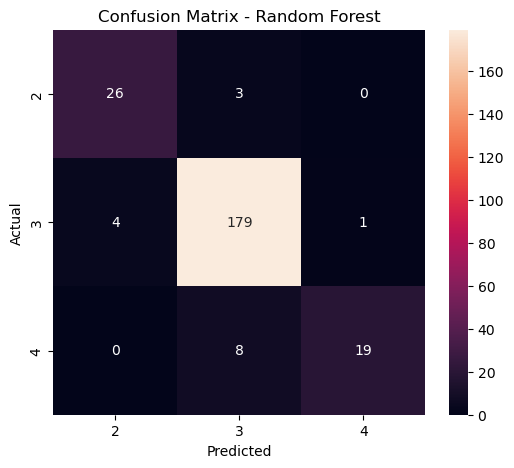

In [42]:
cm = confusion_matrix(y_test, y_pred_RF)

plt.figure(figsize=(6,5))
sns.heatmap(cm, 
            annot=True, 
            fmt="d", 
            cmap="rocket",
            xticklabels=best_model_RF.classes_,
            yticklabels=best_model_RF.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

### Final Business Insights

Based on the exploratory data analysis and machine learning modeling performed on the INX Future Inc. employee dataset, several important insights were identified regarding the factors influencing employee performance.

1. Department-wise Performance Trends

The analysis of performance ratings across departments shows noticeable variations in employee performance. Some departments demonstrate consistently higher performance levels, while others show relatively lower average ratings. This suggests that departmental work environment, leadership quality, and role responsibilities may significantly influence employee productivity and effectiveness.

2. Key Factors Influencing Employee Performance

Using the Random Forest model, feature importance analysis was performed to identify the most influential variables affecting employee performance. The analysis revealed that the following factors have the strongest impact:

- Promotion gap (time since last promotion)

- Experience in the current role and total experience in the company

- Job satisfaction and work environment factors
- Distance from home and employee age

Employees who receive timely promotions and have stable experience in their roles tend to show higher performance levels. Conversely, long delays in promotion or dissatisfaction in the work environment may negatively impact performance.

3. Predictive Model for Employee Performance

Multiple machine learning models were trained and evaluated to predict employee performance. Among them, the Random Forest classifier provided the best results in terms of accuracy and overall predictive capability. This model can effectively predict employee performance based on various employee attributes and can be used by the organization as a decision-support tool.

The predictive model can help the HR department identify employees who may require additional support, training, or motivation to improve their performance.

4. Organizational Implications

The results indicate that employee performance is influenced not only by experience and tenure but also by organizational factors such as promotion policies, job satisfaction, and work environment. Therefore, improving these factors can lead to significant improvements in overall employee productivity.

#### Recommendations to Improve Employee Performance

Based on the insights derived from the analysis, the following recommendations are proposed for INX Future Inc.:

1- Improve Promotion Policies
Reducing long promotion gaps and providing clear career growth opportunities can motivate employees and improve performance levels.

2- Enhance Job Satisfaction and Work Environment
Organizations should focus on creating a positive workplace culture, improving management support, and ensuring employees feel valued.

3- Provide Skill Development and Training Programs
Regular training programs can help employees improve their capabilities and adapt to changing business requirements.

4- Monitor Departments with Lower Performance
Departments showing lower performance levels should be reviewed to identify structural or managerial issues affecting employee productivity.

5- Use Predictive Analytics in HR Decision Making
The developed machine learning model can be integrated into HR systems to predict employee performance during hiring and internal evaluations.

#### Key Insights

️1- Employees with higher job satisfaction consistently show higher performance ratings.

️2- Employees who received more training sessions in the last year performed better.

️3- Departments such as Development and Data Science show stronger performance levels, while certain departments require attention.

️4- Work-life balance strongly influences employee productivity.

️5- Employees who experienced long promotion gaps show lower motivation and performance.

### Conclusion
In this project, employee performance data from INX Future Inc was analyzed to identify the key factors affecting employee performance ratings. Exploratory data analysis revealed that job satisfaction, work-life balance, experience level, and training frequency significantly influence performance outcomes.

Feature engineering techniques were applied to create new features capturing promotion delays, employee loyalty, and workload pressure. Multiple machine learning models were trained, including Logistic Regression, Decision Tree, Random Forest and Support Vector Machine. Among them, the Random Forest model achieved the best predictive performance, demonstrating its ability to capture complex relations between employee attributes and performance and therefore was selected as final model.

Feature importance analysis showed that job satisfaction, training frequency, and work-life balance are the most influential factors affecting employee performance.

These insights enable the organization to take data-driven decisions to improve employee productivity, enhance workplace satisfaction, and maintain its reputation as a leading employer.